__MLP Model For Water Quality Prediction from a Feature Vector (3 Classes)__

Code to load in the merged_metadata Excel file and filter for relevent metadata columns that could be used to predict water quality (0-poor, 1-moderate, 2-good).

Initially, an MLP (Mylti-Layer Perceptron) is trained and evaluated using a feature vector. 

An XGBoost (Extreme Gradient Boosting) model is also trained and evaluated for a comparison. However, the MLP is expected to perform better as MLPs typically perform better with complex feature learning whilst EGBoost is better with structured data, and its performance depends heavily on the dataset.

These models both use all 3 original classes of water quality as targets.
 

Note-the XGBoost model is in progress still

In [ ]:
#Import modules

#Basic
import numpy as np
from pathlib import Path
import pandas as pd
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

#Scikit-learn
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#For the models
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

#Explainability
import shap


/home/teaching/earthwatch-cnn/earthwatch-cnn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Loading the csv
#Setting the path
REPO_NAME = "earthwatch-cnn"
BASE_DIR = next(
    p for p in Path.cwd().parents
    if p.name == REPO_NAME)
DATA_DIR = BASE_DIR / "data"

#Loading the data
merged_df = pd.read_excel(DATA_DIR / "merged_metadata.xlsx")


In [3]:
#Displaying the merged dataframe
merged_df

,downloaded_utc,layer_title,layer_id,feature_object_id,feature_global_id,geometry_x,geometry_y,attachment_id,attachment_global_id,attachment_name,...,feedback_score,County,RBD_NAME,MNCAT_NAME,Nitrate (mg/L) MID,Phosphate (mg/L) MID,Photo URL,x,y,image_path
0,2025-11-26T17:48:11Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,12,f1a757f1-0d0d-4dc5-943d-d2c03e1ba78a,-4.011572,52.434782,6,120e143f-b55e-4c10-aced-8b8f36ab4561,photo-20240525-180858.jpg,...,1,Dyfed,Western Wales,Teifi and North Ceredigion,0.75,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-4.011572,52.434782,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
1,2025-11-26T17:48:17Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,13,3ba0caef-1459-47ca-bcff-bb6a8b253ca4,-1.997459,53.932339,7,01b85181-5e16-4bce-8ec1-864890e0eee6,photo-20240526-115416.jpg,...,2,North Yorkshire,Humber,Aire and Calder,1.50,0.075,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.997459,53.932339,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
2,2025-11-26T17:48:23Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,15,9ab3ef19-b92e-495d-8330-e5cab4f52139,-0.490153,51.398517,8,93b0b358-2840-496f-9c50-beb08e550091,photo-20240531-072047.jpg,...,3,Surrey,Thames,Maidenhead and Sunbury,7.50,0.150,https://services3.arcgis.com/SQtySBftABENTpkx/...,-0.490153,51.398517,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
3,2025-11-26T17:48:29Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,16,7065d44e-868d-41a8-bc29-3e380d44a284,-1.705773,53.341469,9,967fdeb6-6016-43ed-954a-e2778dd0fe31,photo-20240531-184342.jpg,...,1,Derbyshire,Humber,Derwent Derbyshire,0.75,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.705773,53.341469,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
4,2025-11-26T17:48:35Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,17,ece94aea-b3a2-4c72-a1b0-66b329185eb8,-1.633728,53.797123,10,e895f878-0577-40ae-9a49-ecd991ffcf85,photo-20240601-110123.jpg,...,3,West Yorkshire,Humber,Aire and Calder,3.50,0.035,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.633728,53.797123,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8999,2025-11-27T14:03:26Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11545,7479327a-dda2-4647-8e19-176fc7b7c208,-1.776789,53.921762,9974,a538e4f9-dda1-437e-8f73-952f969aa748,IMG_20251108_151702379_HDR.jpg,...,3,West Yorkshire,Humber,Wharfe and Ouse Lower,10.00,1.000,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.776789,53.921762,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
9000,2025-11-27T14:03:36Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11546,9ca17c49-6a38-405f-8369-caebcbb4c445,-1.682858,53.910390,9975,d6c0b93c-614f-40f8-8129-362d9b85f4b7,IMG_20251112_123816085_HDR.jpg,...,1,West Yorkshire,Humber,Wharfe and Ouse Lower,0.35,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.682858,53.910390,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
9001,2025-11-27T14:03:47Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11547,f077fd29-55c0-484c-8b03-aa1d54844b54,-1.659827,53.913112,9976,1869abcf-7f8f-4a66-86ea-c1a2b0faaef3,IMG_20251112_130858731_HDR.jpg,...,1,North Yorkshire,Humber,Wharfe and Ouse Lower,0.35,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.659827,53.913112,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
9002,2025-11-27T14:03:57Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11548,8279d341-cfc1-4852-8b19-a58dc6eee304,-1.625267,53.904750,9977,4af7180e-6b14-4fce-8190-948063dbb8d2,IMG_20251122_091305231_HDR.jpg,...,2,North Yorkshire,Humber,Wharfe and Ouse Lower,1.50,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.625267,53.904750,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...


In [4]:
#Selecting only the columns we want
#Not selecting any empty columns

filtered_df=merged_df[["feature_global_id", "feedback_score","Freshwater body type","What is the main land use within 50m?","You selected other, what is the main land use?", 
                       "What is the main bank vegetation? (select all that apply)","You selected other, what is the main bank vegetation?","Vegetation cover in/on the water (%)",
                       "Is there any of the following on the water surface?", "Estimate the water colour","You selected other, enter the colour"]]

#Displaying the filtered dataframe
filtered_df
#feedback score - 1-poor, 3-good -changes to 0...2

,feature_global_id,feedback_score,Freshwater body type,What is the main land use within 50m?,"You selected other, what is the main land use?",What is the main bank vegetation? (select all that apply),"You selected other, what is the main bank vegetation?",Vegetation cover in/on the water (%),Is there any of the following on the water surface?,Estimate the water colour,"You selected other, enter the colour"
0,f1a757f1-0d0d-4dc5-943d-d2c03e1ba78a,1,River,Forest,NaN,Trees_shrubs,NaN,NaN,NaN,Colourless,NaN
1,3ba0caef-1459-47ca-bcff-bb6a8b253ca4,2,Stream,Rural_residential,NaN,"Grass_small_plants,Trees_shrubs",NaN,NaN,NaN,Colourless,NaN
2,9ab3ef19-b92e-495d-8330-e5cab4f52139,3,River,Urban_green_space,NaN,Trees_shrubs,NaN,NaN,NaN,Colourless,NaN
3,7065d44e-868d-41a8-bc29-3e380d44a284,1,River,Livestock,NaN,"Trees_shrubs,Grass_small_plants",NaN,NaN,Foam,Brown,NaN
4,ece94aea-b3a2-4c72-a1b0-66b329185eb8,3,River,Urban_green_space,NaN,"Trees_shrubs,Grass_small_plants,Concrete_imper...",NaN,NaN,NaN,Colourless,NaN
...,...,...,...,...,...,...,...,...,...,...,...
8999,7479327a-dda2-4647-8e19-176fc7b7c208,3,River,Grassland_shrub,NaN,"Trees_shrubs,Grass_small_plants",NaN,NaN,Foam,Brown,NaN
9000,9ca17c49-6a38-405f-8369-caebcbb4c445,1,River,Urban_green_space,NaN,"Trees_shrubs,Grass_small_plants,Bare_soil",NaN,NaN,Foam,Brown,NaN
9001,f077fd29-55c0-484c-8b03-aa1d54844b54,1,River,Arable_agricultural,NaN,"Trees_shrubs,Grass_small_plants",NaN,NaN,Foam,Brown,NaN
9002,8279d341-cfc1-4852-8b19-a58dc6eee304,2,River,Livestock,NaN,"Trees_shrubs,Grass_small_plants,Bare_soil",NaN,NaN,NaN,Colourless,NaN


In [ ]:
#Dataframe pre-processing for ML training 
#Need to change the data from categories to numerical values and normalise. 

#Splitting the columns into different data types. 
multilabel_col = "What is the main bank vegetation? (select all that apply)"
nominal_cols = [
    "Freshwater body type",
    "What is the main land use within 50m?",
    "Is there any of the following on the water surface?",
    "Estimate the water colour"
]
numeric_cols = ["Vegetation cover in/on the water (%)"]
TARGET = "feedback_score"

filtered_df = filtered_df.copy()

def normalize_multilabel(x):
    #Explicit handling for list/array-like types (do this first)
    if isinstance(x, (list, tuple, set, np.ndarray)):
        #Convert to plain python list of stripped strings
        out = []
        for v in x:
            if v is None:
                continue
            s = str(v).strip()
            if s and s.lower() not in ("nan", "none"):
                out.append(s)
        return out

    #Now use pd.isna
    if pd.isna(x):
        return []

    #Split strings/other scalars on the comma
    s = str(x).strip()
    if s == "" or s.lower() in ("nan", "none"):
        return []
    parts = [p.strip() for p in s.split(",") if p.strip()]
    return parts

#Apply normalization
filtered_df.loc[:, multilabel_col] = filtered_df[multilabel_col].apply(normalize_multilabel)

#Build the bank_veg_df using MultiLabelBinarizer
mlb = MultiLabelBinarizer()
bank_veg_encoded = mlb.fit_transform(filtered_df[multilabel_col])
bank_veg_df = pd.DataFrame(
    bank_veg_encoded,
    index=filtered_df.index,
    columns=[f"bankveg_{c}" for c in mlb.classes_]
)
print("bank_veg_df.shape:", bank_veg_df.shape)
print("bankveg classes (sample):", mlb.classes_[:20])

#Ensure nominal columns are strings
def to_str_val(v):
    if isinstance(v, (list, tuple, set, np.ndarray)):
        return "|".join([str(x).strip() for x in v if x is not None and str(x).strip().lower() not in ("nan","none")])
    if pd.isna(v):
        return ""
    return str(v).strip()

for c in nominal_cols:
    filtered_df.loc[:, c] = filtered_df[c].apply(to_str_val)

#Numeric fill
filtered_df.loc[:, numeric_cols] = filtered_df[numeric_cols].astype(float).fillna(0.0)

#ColumnTransformer (exclude multi-label col)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
        ("num", StandardScaler(), numeric_cols),
    ],
    remainder="drop"
)

X_base_arr = preprocessor.fit_transform(filtered_df)

#Check if X_base_arr is sparse and make dense
try:
    from scipy import sparse
    if sparse.issparse(X_base_arr):
        X_base_arr = X_base_arr.toarray()
except Exception:
    pass

#Set column names
try:
    cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(nominal_cols)
    base_cols = list(numeric_cols) + list(cat_names)
except Exception:
    base_cols = [f"base_{i}" for i in range(X_base_arr.shape[1])]

X_base_df = pd.DataFrame(X_base_arr, index=filtered_df.index, columns=base_cols[:X_base_arr.shape[1]])
bank_veg_df = bank_veg_df.reindex(filtered_df.index).fillna(0).astype(int)
X_df = pd.concat([X_base_df, bank_veg_df], axis=1)
X = X_df.values
y = filtered_df[TARGET].astype(int).values - 1

#Check shapes
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)


bank_veg_df.shape: (9004, 5)
bankveg classes (sample): ['Bare_soil' 'Concrete_impermeable_surface' 'Grass_small_plants' 'Other'
 'Trees_shrubs']
Final X shape: (9004, 64)
Final y shape: (9004,)


In [9]:
#Checking the shapes of X and y and the new target classes, now 0..2 instead of 1..3
print("X shape:", X.shape)   # (n_samples, n_features)
print("y shape:", y.shape)   # (n_samples,)
print("y classes:", np.unique(y))

X shape: (9004, 64)
y shape: (9004,)
y classes: [0 1 2]


In [10]:
#Divide the data into training, validation and testing. 

#Split test off from training+validation
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y)

#Split train into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, random_state=42, stratify=y_temp)
#Final 80/10/10 split

print(X_train.shape, X_val.shape, X_test.shape)


(7202, 64) (901, 64) (901, 64)


In [ ]:
#MPL model
#Training

#Setting parameters and loading training data
num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

#Cap extreme weights
for k in class_weight:
    class_weight[k] = min(class_weight[k], 3.0)

#Building the model using keras with dropout
model = tf.keras.Sequential([
    layers.Input(shape=(X.shape[1],)),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

#Setting Adam as the optimiser
opt = tf.keras.optimizers.Adam(learning_rate=1e-4)   # try 1e-4 or 5e-5
model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Early stopping to prevent overfitting
es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)

#Storing the model history
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[es,rlr]
)

#Evaluating the model on the test set
y_test_cat = to_categorical(y_test, num_classes)
y_val_cat = to_categorical(y_val, num_classes)

test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test accuracy:", test_acc)

#Detailed classification metrics on validation set
y_val_proba = model.predict(X_val)
y_val_pred = np.argmax(y_val_proba, axis=1)
y_val_true = np.argmax(y_val_cat, axis=1)

#Compute metrics
print("\nValidation accuracy:", accuracy_score(y_val_true, y_val_pred))
print("\nClassification report (val):")
print(classification_report(y_val_true, y_val_pred, digits=4))

print("\nConfusion matrix (val):")
print(confusion_matrix(y_val_true, y_val_pred))


Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3674 - loss: 1.1602 - val_accuracy: 0.4018 - val_loss: 1.1538 - learning_rate: 1.0000e-04
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3845 - loss: 1.1510 - val_accuracy: 0.4218 - val_loss: 1.1412 - learning_rate: 1.0000e-04
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4110 - loss: 1.1430 - val_accuracy: 0.4395 - val_loss: 1.1347 - learning_rate: 1.0000e-04
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4293 - loss: 1.1347 - val_accuracy: 0.4428 - val_loss: 1.1284 - learning_rate: 1.0000e-04
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4402 - loss: 1.1277 - val_accuracy: 0.4428 - val_loss: 1.1224 - learning_rate: 1.0000e-04
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4388 - loss: 1.1230 - val_accuracy: 0.4462 - val_loss: 1.1150 - learning_rate: 1.0000e-04
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 

With no weights:
The model is learning real signals but its performance is uneven across classes: Class 1 (moderate) is effectively not being learned
The overall accuracy (~0.50) is meaningful but misleading on its own.
Class 0: precision: 0.51, recall: 0.43, F1: 0.46, Support 326 - Moderarely learned, but confused with class 2?\
Class 1: precision and recall and F1: 0.00, support: 187. Class 1 is never predicted correctly. \
Class 2: precision: 0.49, recall: 0.79, F1: 0.61, Support: 388. Best learned class. 

With class-weighting: The validation accuracy dropped because the model stopped over-predicting class 2. However the class 1 recall and the macro F1 increased. (F1 is an unweighted average of the F1 scores for each individual class)


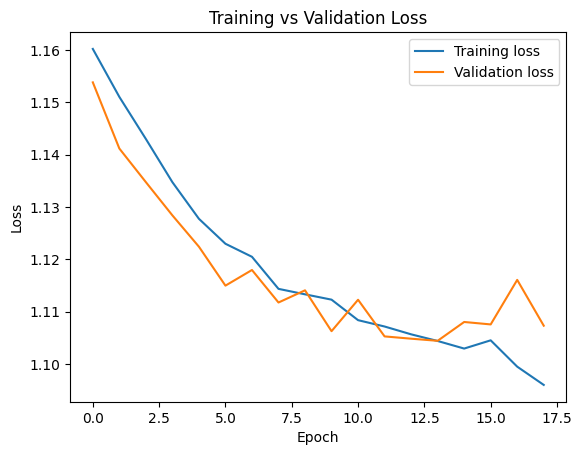

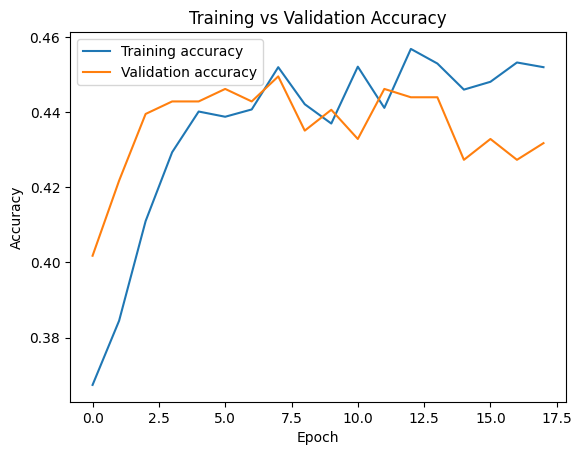

In [37]:
#Inspection of training process
#Loss curve
plt.figure()
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

#Accuracy curve
plt.figure()
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()


Mild overfitting after 10-15 epochs. \
Training accuracy steadily improves to 0.51. Validation accuracy tracks it closely, reaching 0.50 to 0.505. 

In [ ]:
#SHAP PLOTS FOR EACH CLASS HERE

In [64]:
#XGBOOST model

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(X_train, y_train)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


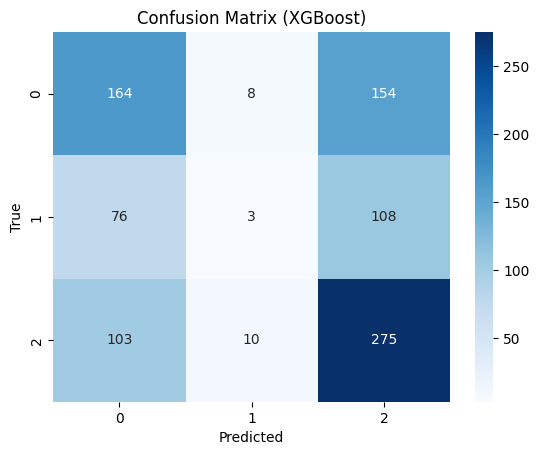

In [ ]:
#Plotting confusion matrix
#Predict class labels
y_val_pred = xgb.predict(X_val)
#Probabilities
y_val_proba = xgb.predict_proba(X_val)
if y_val_pred.ndim == 2 and y_val_pred.shape[1] > 1:
    y_val_pred_labels = np.argmax(y_val_pred, axis=1)
else:
    y_val_pred_labels = y_val_pred  # leave as-is, will be checked below   

cm = confusion_matrix(y_val, y_val_pred_labels)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (XGBoost)")
plt.show()


In [71]:
# majority-class baseline
majority_acc = (y_val == np.bincount(y_train).argmax()).mean()
print("Majority class baseline accuracy:", majority_acc)

Majority class baseline accuracy: 0.4306326304106548


In [72]:
#Finding out which features are most important in the classification
importances = xgb.feature_importances_
feat_imp = pd.Series(importances, index=X_df.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print(feat_imp.head(20))


Freshwater body type_Ditch                                                   0.045428
What is the main land use within 50m?_Arable_agricultural                    0.038120
What is the main land use within 50m?_Industrial_commercial                  0.037766
Freshwater body type_Other                                                   0.032134
Estimate the water colour_Colourless                                         0.029500
What is the main land use within 50m?_                                       0.028819
Is there any of the following on the water surface?_Floating_algae,Slurry    0.028712
Estimate the water colour_Green                                              0.023906
Is there any of the following on the water surface?_Oily_sheen               0.023282
What is the main land use within 50m?_Urban_green_space                      0.022149
Freshwater body type_River                                                   0.022086
What is the main land use within 50m?_Livestock       